### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('max_colwidth', 100)

In [4]:
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t', index_col=0)
df

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or w...,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eo...","monitor blood pressure , weight and asses for resolution of fluid"
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's al...","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but...","I Hate This Birth Control, I Would Not Suggest This To Anyone."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they would leave me balled up in bed for at least 2 da...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as need...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months after just a few days of being on the drug. The heart...,"Constipation, dry mouth and some mild dizziness that would go away after medication was stopped ...","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every mo..."
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too s...",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme...,See above
...,...,...,...,...,...,...,...,...
1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Better able to pay attention and absorb information in...","Restless legs at night, insomnia, headache (sometimes pretty bad). Also, make sure you take it a...","I took adderall once as a child, and it made me so miserable that I never wanted to take it agai..."
3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day, insomnia at night, bad effect on libido and sexua...","I was on Zoloft for about 2 years total. I am extremely sensitive to medication, so I started at..."
1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,"Constant issues with the patch not staying on. I called the manufacture (Bayer), they took down...",---
2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked up to 4 doses per day over a six month period. Onl...


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3107 non-null   object
 6   sideEffectsReview  3105 non-null   object
 7   commentsReview     3099 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


In [6]:
df['urlDrugName'].value_counts()

lexapro      63
prozac       46
retin-a      45
zoloft       45
propecia     38
             ..
mirena        1
xanax-xr      1
omnitrope     1
cataflam      1
trileptal     1
Name: urlDrugName, Length: 502, dtype: int64

In [9]:
len(df.duplicated())
sum(df.duplicated())

31

In [10]:
df = df.drop_duplicates()
len(df)

3076

In [12]:
df.describe(include='all')

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
count,3076,3076.000000,3076,3076,3075,3076,3074,3068
unique,502,NaN,5,5,1426,3032,2814,3047
top,lexapro,NaN,Highly Effective,Mild Side Effects,depression,none,none,none
freq,60,NaN,1317,1007,229,20,112,6
mean,NaN,6.998375,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.944859,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df['effectiveness'].value_counts()

Highly Effective          1317
Considerably Effective     916
Moderately Effective       413
Ineffective                247
Marginally Effective       183
Name: effectiveness, dtype: int64

In [14]:
df['sideEffects'].value_counts()

Mild Side Effects                1007
No Side Effects                   918
Moderate Side Effects             609
Severe Side Effects               367
Extremely Severe Side Effects     175
Name: sideEffects, dtype: int64

In [15]:
df['condition'].value_counts()

depression                                          229
acne                                                164
anxiety                                              63
insomnia                                             54
birth control                                        49
                                                   ... 
all over and various type pain                        1
excessive coughing, later diagnosed as pneumonia      1
after birth thyroid not working to mormal levelc      1
chest infection (viral)                               1
total hysterctomy                                     1
Name: condition, Length: 1426, dtype: int64

In [20]:
lista_palabras = []

for condition in df['condition'].str.split(" "):
    if type(condition) != float:
        for palabra in condition:
            lista_palabras.append(palabra.replace(',','').lower())

pd.Series(lista_palabras).value_counts()[:10]

depression    315
acne          219
anxiety       140
pain          129
and           104
infection     100
high           96
insomnia       73
disorder       67
allergies      62
dtype: int64

#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [21]:
pd.get_dummies(df['effectiveness'])

,Considerably Effective,Highly Effective,Ineffective,Marginally Effective,Moderately Effective
2202,0,1,0,0,0
3117,0,1,0,0,0
1146,0,1,0,0,0
3947,0,0,0,1,0
1951,0,0,0,1,0
...,...,...,...,...,...
1039,0,1,0,0,0
3281,0,0,1,0,0
1664,0,0,0,1,0
2621,1,0,0,0,0


In [23]:
df['effectiveness'].unique()

array(['Highly Effective', 'Marginally Effective', 'Ineffective',
       'Considerably Effective', 'Moderately Effective'], dtype=object)

In [28]:
my_effectiveness = {
    "Ineffective": 0,
    "Marginally Effective": 1,
    "Moderately Effective": 2,
    "Considerably Effective": 3,
    "Highly Effective": 4
}

df['effectiveness_int'] = df['effectiveness'].map(my_effectiveness)

C:\Users\Miguel Angel\AppData\Local\Temp\ipykernel_568\1968426100.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['effectiveness_int'] = df['effectiveness'].map(my_effectiveness)


In [29]:
df

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,effectiveness_int
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or w...,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eo...","monitor blood pressure , weight and asses for resolution of fluid",4
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's al...","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but...","I Hate This Birth Control, I Would Not Suggest This To Anyone.",4
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they would leave me balled up in bed for at least 2 da...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as need...,4
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months after just a few days of being on the drug. The heart...,"Constipation, dry mouth and some mild dizziness that would go away after medication was stopped ...","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every mo...",1
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too s...",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme...,See above,1
...,...,...,...,...,...,...,...,...,...
1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Better able to pay attention and absorb information in...","Restless legs at night, insomnia, headache (sometimes pretty bad). Also, make sure you take it a...","I took adderall once as a child, and it made me so miserable that I never wanted to take it agai...",4
3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day, insomnia at night, bad effect on libido and sexua...","I was on Zoloft for about 2 years total. I am extremely sensitive to medication, so I started at...",0
1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,"Constant issues with the patch not staying on. I called the manufacture (Bayer), they took down...",---,1
2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked up to 4 doses per day over a six month period. Onl...,3


In [30]:
df['sideEffects'].unique()

array(['Mild Side Effects', 'Severe Side Effects', 'No Side Effects',
       'Extremely Severe Side Effects', 'Moderate Side Effects'],
      dtype=object)

In [36]:
my_sideEffects = {
    "No Side Effects": 0,
    "Mild Side Effects": 1,
    "Moderate Side Effects": 2,
    "Severe Side Effects": 3,
    "Extremely Severe Side Effects": 4
}

df['sideEffects_int'] = df['sideEffects'].map(my_sideEffects)

C:\Users\Miguel Angel\AppData\Local\Temp\ipykernel_568\2837915483.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sideEffects_int'] = df['sideEffects'].map(my_sideEffects)


In [37]:
X = df[['rating', 'effectiveness_int', 'sideEffects_int']]
print(X.shape)

(3076, 3)


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
model = KMeans(n_init='auto')
model.fit(X)
model.predict(X)

array([7, 1, 2, ..., 5, 6, 7])

In [42]:
model.score(X)

-3603.414147799635

In [43]:
silhouette_score(X, model.predict(X))

0.3680695006834145

In [44]:
km_list = [KMeans(n_clusters=k, n_init='auto').fit(X) for k in range(2,30)]
km_list

[KMeans(n_clusters=2, n_init='auto'),
 KMeans(n_clusters=3, n_init='auto'),
 KMeans(n_clusters=4, n_init='auto'),
 KMeans(n_clusters=5, n_init='auto'),
 KMeans(n_clusters=6, n_init='auto'),
 KMeans(n_clusters=7, n_init='auto'),
 KMeans(n_init='auto'),
 KMeans(n_clusters=9, n_init='auto'),
 KMeans(n_clusters=10, n_init='auto'),
 KMeans(n_clusters=11, n_init='auto'),
 KMeans(n_clusters=12, n_init='auto'),
 KMeans(n_clusters=13, n_init='auto'),
 KMeans(n_clusters=14, n_init='auto'),
 KMeans(n_clusters=15, n_init='auto'),
 KMeans(n_clusters=16, n_init='auto'),
 KMeans(n_clusters=17, n_init='auto'),
 KMeans(n_clusters=18, n_init='auto'),
 KMeans(n_clusters=19, n_init='auto'),
 KMeans(n_clusters=20, n_init='auto'),
 KMeans(n_clusters=21, n_init='auto'),
 KMeans(n_clusters=22, n_init='auto'),
 KMeans(n_clusters=23, n_init='auto'),
 KMeans(n_clusters=24, n_init='auto'),
 KMeans(n_clusters=25, n_init='auto'),
 KMeans(n_clusters=26, n_init='auto'),
 KMeans(n_clusters=27, n_init='auto'),
 KMeans(

In [45]:
silhouette_score_list = [silhouette_score(X, model.labels_) for model in km_list]
silhouette_score_list

[0.6202329963099731,
 0.4541698281460479,
 0.41848098574144665,
 0.41493000747805475,
 0.3654900617822822,
 0.3703357280103999,
 0.404959118795111,
 0.3830792222987881,
 0.3688052423759335,
 0.38885634298288735,
 0.43923008622106935,
 0.4598778733959965,
 0.4301993207142387,
 0.41020147847326865,
 0.43042711769436154,
 0.43726923647362276,
 0.5027128765964896,
 0.5108338407292969,
 0.4930474289459992,
 0.5016742051781149,
 0.5407860913674949,
 0.5049333114621688,
 0.5529595317481074,
 0.5859793543714104,
 0.5614072664064071,
 0.5718888931343384,
 0.5803025077204489,
 0.6240065226015901]

Text(0, 0.5, 'silhouette_score')

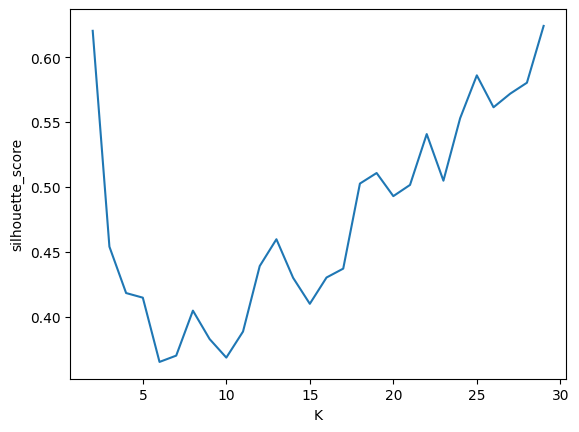

In [46]:
plt.plot(range(2,30), silhouette_score_list)
plt.xlabel("K")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'inertias')

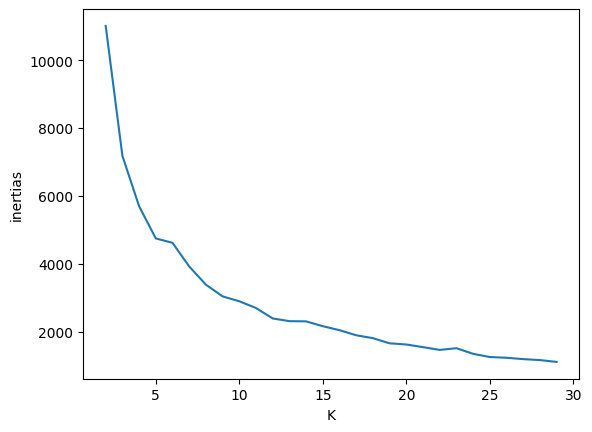

In [47]:
inertias = [model.inertia_ for model in km_list]
plt.plot(range(2,30), inertias)
plt.xlabel("K")
plt.ylabel("inertias")

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [75]:
kmeans = KMeans(n_clusters=2, n_init='auto').fit(X)
kmeans.labels_

array([1, 1, 0, ..., 1, 0, 1])

In [76]:
df_cluster = X.copy()
df_cluster['cluster'] = kmeans.labels_
df_cluster

,rating,effectiveness_int,sideEffects_int,cluster
2202,4,4,1,1
3117,1,4,3,1
1146,10,4,0,0
3947,3,1,1,1
1951,2,1,3,1
...,...,...,...,...
1039,10,4,1,0
3281,1,0,4,1
1664,2,1,2,1
2621,8,3,1,0


In [77]:
df_cluster['cluster'].value_counts()

0    2257
1     819
Name: cluster, dtype: int64

<Axes: ylabel='cluster'>

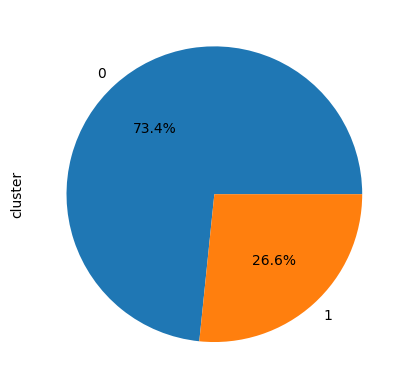

In [78]:
df_cluster['cluster'].value_counts().plot.pie(autopct="%.1f%%")

In [79]:
pd.set_option('display.max_columns', 100)

In [80]:
df_cluster.groupby('cluster').describe()

rating                                                 \
          count      mean       std  min  25%  50%   75%   max   
cluster                                                          
0        2257.0  8.573327  1.268151  5.0  8.0  9.0  10.0  10.0   
1         819.0  2.658120  1.568436  1.0  1.0  3.0   4.0   6.0   

        effectiveness_int                                               \
                    count      mean       std  min  25%  50%  75%  max   
cluster                                                                  
0                  2257.0  3.424457  0.705654  1.0  3.0  4.0  4.0  4.0   
1                   819.0  1.582418  1.358297  0.0  0.0  1.0  3.0  4.0   

        sideEffects_int                                               
                  count      mean       std  min  25%  50%  75%  max  
cluster                                                               
0                2257.0  0.882144  0.839688  0.0  0.0  1.0  1.0  4.0  
1                 819.0  2.484737  1.181851  0.0  2.0  3.0  3.0  4.0

In [81]:
kmeans.cluster_centers_

array([[8.57332743, 3.42445724, 0.88214444],
       [2.65811966, 1.58241758, 2.48473748]])

In [82]:
kmeans.transform(X)

array([[4.61090698, 3.13843799],
       [7.8849128 , 2.97650147],
       [1.77336486, 8.11922608],
       ...,
       [7.09480285, 1.00364444],
       [0.72302021, 5.72273282],
       [4.91874001, 1.48660296]])

In [83]:
import plotly.express as px

fig = px.scatter_3d(df_cluster, x="rating", y="effectiveness_int", z="sideEffects_int", color="cluster")
fig.show()